In [12]:
source("SeuratCropper.R")

In [5]:
library(data.table)
library(sf)
library(geojsonsf)
library(Seurat)
library(arrow)
library(dplyr)
library(cowplot)
library(ggplot2)


Attaching package: 'arrow'


The following object is masked from 'package:utils':

    timestamp



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




### GeoJSON file created by cropping ATN in QuPath from Male Sag16 ID57700

In [3]:
setwd("/Users/grifclay/Desktop/Projects/Spatial_Transcriptomics_Analysis")

In [4]:
obj <- LoadXenium("data/Male/20251113_MS_Sag16_ID57700", fov="fov")

10X data contains more than one type and is being returned as a list containing matrices of each type.

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


In [5]:
saveRDS(obj, file = "C:/Users/grifclay/Desktop/Projects/Spatial_Transcriptomics_Analysis/Routput/Male_Sag_16")

In [6]:
obj <- readRDS("C:/Users/grifclay/Desktop/Projects/Spatial_Transcriptomics_Analysis/Routput/Male_Sag_16")

In [7]:
Polygon_ATN <- geojson_sf("data/cropping/coords/male_sag16_ATN_formatted.geojson")

In [13]:
ATN_obj = PolygonCropSeurat(obj, list(fov = Polygon_ATN))

Start cropping fovs...

Processing centroids...

Found 1512 cells.

Processing molecules (Chunked Filter)...

Done processing molecules.

Creating final object...

Done: fov

Warning message:
"Not validating FOV objects"
Warning message:
"Not validating Centroids objects"
Warning message:
"Not validating Centroids objects"
Warning message:
"Not validating FOV objects"
Warning message:
"Not validating FOV objects"
Warning message:
"Not validating FOV objects"
Warning message:
"Not validating Seurat objects"


In [14]:
dim(ATN_obj)
dim(obj)

[1] 5006 1512

[1]   5006 225002

In [15]:
Images(ATN_obj)

[1] "fov"

Warning message:
"The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


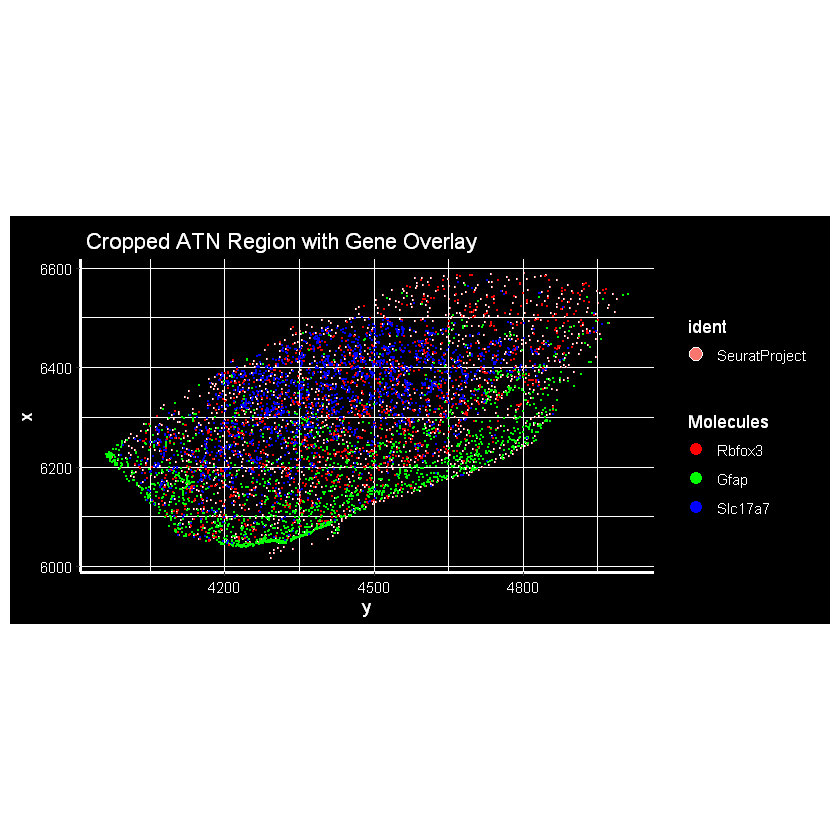

In [16]:
genes_to_plot <- c("Rbfox3", "Gfap", "Slc17a7") # Adjust these to genes in your panel!

# Plotting
ImageDimPlot(
  ATN_obj, 
  fov = "fov",            # The name of your FOV (check Images(ATN_obj))
  molecules = genes_to_plot,
  mols.size = 0.3,        # Adjust dot size for molecules
  mols.cols = c("red", "green", "blue"), # Colors for the genes
  border.color = "white", # Color of the cell segmentation lines
  axes = TRUE
) + 
  ggtitle("Cropped ATN Region with Gene Overlay")